# Part A: interactive conformer searches and AQME descriptors

Start the workshop here and run one cell at a time so that every intermediate structure, command, and result is visible. Using molecule **A1**, we build and search structures manually with RDKit and CREST, then apply AQME QDESCP to the existing ensemble without resampling it.

Notebook-generated files are kept under `outputs/notebook/`, separate from command-line results.

## One-time Jupyter setup

After creating the environment from the official AQME instructions, add Jupyter if it is not already installed:

```bash
conda install -n aqme -c conda-forge jupyterlab ipykernel
conda activate aqme
cd descriptor_generation
jupyter lab AQME_descriptor_and_conformer_workshop.ipynb
```

Select the **aqme** Python kernel. Start Jupyter from this workshop directory so the path checks below succeed.

In [1]:
# A line beginning with # is an explanatory comment. Python ignores it.
molecule_name = 'A1'  # A variable gives a value a reusable name.
print('Our example molecule is', molecule_name)

Our example molecule is A1


The previous cell contains a **comment**, a **variable**, a text value in quotation marks, and a **function call**. Run it with Shift-Return. Change `A1` to another name, run it again, and observe that the output changes.

In [2]:
# A list stores several values in order.
mapped_atom_labels = [1, 2, 3]
print('Mapped atom labels:', mapped_atom_labels)
print('Number of mapped atoms:', len(mapped_atom_labels))

Mapped atom labels: [1, 2, 3]
Number of mapped atoms: 3


## Load the tools

Python begins with a small built-in vocabulary. An `import` loads additional tools. The next cell imports file-handling tools, pandas for tables, and RDKit for chemistry. You do not need to memorize the import lines.

In [3]:
from importlib.metadata import version
from pathlib import Path
import csv
import os
import shutil
import subprocess
import sys

import pandas as pd
from rdkit import Chem, rdBase
from rdkit.Chem import AllChem, Draw

WORKSHOP_DIR = Path.cwd().resolve()
INPUT_CSV = WORKSHOP_DIR / 'inputs' / 'A1.csv'
if not INPUT_CSV.exists():
    raise FileNotFoundError(
        'Start Jupyter from descriptor_generation so inputs/A1.csv is available.'
    )
NOTEBOOK_OUTPUTS = WORKSHOP_DIR / 'outputs' / 'notebook'
NOTEBOOK_OUTPUTS.mkdir(parents=True, exist_ok=True)

print('Python:', sys.version.split()[0])
print('AQME:', version('aqme'))
print('RDKit:', rdBase.rdkitVersion)
print('CREST executable:', shutil.which('crest'))
print('Notebook outputs:', NOTEBOOK_OUTPUTS)

Python: 3.12.12
AQME: 2.0.1
RDKit: 2025.09.1
CREST executable: /Users/luccapfitzer/anaconda3/envs/aqme/bin/crest
Notebook outputs: /Users/luccapfitzer/Workflow-Meetings/descriptor_generation/outputs/notebook


## 1. Read and inspect the mapped SMILES

The command line passes the CSV directly to AQME. In a notebook, we can inspect the same input before running anything.

,SMILES,code_name
0,O=C([CH-:1]/[N:2]=[CH:3]/C1=CC=CC=C1)OC,A1


Formal charge: -1
Mapped atoms: {1: 'C', 2: 'N', 3: 'C'}


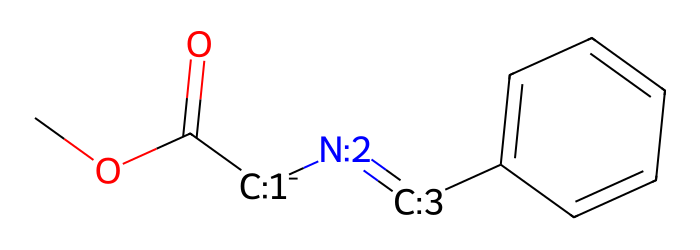

In [4]:
input_table = pd.read_csv(INPUT_CSV)
display(input_table)

code_name = input_table.loc[0, 'code_name']
smiles = input_table.loc[0, 'SMILES']
mol = Chem.MolFromSmiles(smiles)
if mol is None:
    raise ValueError(f'RDKit could not parse {smiles}')

formal_charge = Chem.GetFormalCharge(mol)
mapped_atoms = {
    atom.GetAtomMapNum(): atom.GetSymbol()
    for atom in mol.GetAtoms()
    if atom.GetAtomMapNum()
}
print('Formal charge:', formal_charge)
print('Mapped atoms:', mapped_atoms)
Draw.MolToImage(mol, size=(700, 250))

## 2. Convert SMILES to XYZ with native RDKit

Command-line equivalent: `python scripts/smiles_to_xyz.py`. The cell below exposes the same parse → add H → embed → optimize → write sequence.

In [5]:
mol_3d = Chem.AddHs(Chem.Mol(mol))
embed_parameters = AllChem.ETKDGv3()
embed_parameters.randomSeed = 20260726
embed_parameters.enforceChirality = True
if AllChem.EmbedMolecule(mol_3d, embed_parameters) != 0:
    raise RuntimeError('ETKDGv3 embedding failed')

if AllChem.MMFFHasAllMoleculeParams(mol_3d):
    force_field = 'MMFF94'
    not_converged = AllChem.MMFFOptimizeMolecule(mol_3d, maxIters=1000)
else:
    force_field = 'UFF'
    not_converged = AllChem.UFFOptimizeMolecule(mol_3d, maxIters=1000)

xyz_dir = NOTEBOOK_OUTPUTS / '01_smiles_to_xyz'
xyz_dir.mkdir(parents=True, exist_ok=True)
xyz_path = xyz_dir / 'A1.xyz'
xyz_lines = Chem.MolToXYZBlock(mol_3d).splitlines()
xyz_lines[1] = (
    f'{code_name}; RDKit ETKDGv3/{force_field}; charge={formal_charge}; '
    'multiplicity=1; atom_maps=1:C,2:N,3:C'
)
xyz_path.write_text('\n'.join(xyz_lines) + '\n', encoding='utf-8')

print('Optimization converged:', not_converged == 0)
print('Wrote:', xyz_path)
print('\n'.join(xyz_lines[:8]))

Optimization converged: True
Wrote: /Users/luccapfitzer/Workflow-Meetings/descriptor_generation/outputs/notebook/01_smiles_to_xyz/A1.xyz
23
A1; RDKit ETKDGv3/MMFF94; charge=-1; multiplicity=1; atom_maps=1:C,2:N,3:C
O      4.257992   -1.192685    0.915463
C      3.268399   -0.566014    0.563448
C      1.901828   -1.122540    0.667028
N      0.775833   -0.439800    0.279054
C     -0.347537   -1.063780    0.433266
C     -1.636559   -0.446751    0.057368


## 3. Run an RDKit conformer search in Python

Command-line equivalent: `python scripts/rdkit_conformer_search.py`. We reuse its tested optimization and RMSD-pruning helpers, while keeping the ensemble and table live in the notebook.

In [6]:
sys.path.insert(0, str(WORKSHOP_DIR))
from scripts.rdkit_conformer_search import (
    one_conformer_record,
    optimize_conformers,
    prune_by_heavy_atom_rmsd,
    xyz_block,
)

NUM_CONFS = 100
RMSD_THRESHOLD = 0.50
MAX_KEEP = 20

ensemble_mol = Chem.AddHs(Chem.Mol(mol))
parameters = AllChem.ETKDGv3()
parameters.randomSeed = 20260726
parameters.enforceChirality = True
parameters.pruneRmsThresh = -1.0
parameters.numThreads = 0
conformer_ids = list(
    AllChem.EmbedMultipleConfs(ensemble_mol, numConfs=NUM_CONFS, params=parameters)
)
method, optimization_results = optimize_conformers(ensemble_mol, conformer_ids)
ranked_ids = sorted(conformer_ids, key=lambda cid: optimization_results[cid][1])
kept_ids = prune_by_heavy_atom_rmsd(
    ensemble_mol, ranked_ids, RMSD_THRESHOLD, MAX_KEEP
)
minimum_energy = optimization_results[kept_ids[0]][1]

rdkit_rows = []
for rank, conformer_id in enumerate(kept_ids, start=1):
    not_converged, energy = optimization_results[conformer_id]
    rdkit_rows.append({
        'rank': rank,
        'conformer_id': conformer_id,
        'force_field': method,
        'energy_kcal_mol': energy,
        'relative_energy_kcal_mol': energy - minimum_energy,
        'optimization_converged': not_converged == 0,
    })
rdkit_summary = pd.DataFrame(rdkit_rows)

rdkit_dir = NOTEBOOK_OUTPUTS / '02_rdkit_search'
rdkit_dir.mkdir(parents=True, exist_ok=True)
rdkit_summary.to_csv(rdkit_dir / 'rdkit_summary.csv', index=False)
sdf_writer = Chem.SDWriter(str(rdkit_dir / 'A1_rdkit.sdf'))
canonical_smiles = Chem.MolToSmiles(mol)
ensemble_xyz = []
for row, conformer_id in zip(rdkit_rows, kept_ids):
    record = one_conformer_record(ensemble_mol, conformer_id)
    record.SetProp('_Name', f"A1_rdkit_conf_{row['rank']}")
    record.SetDoubleProp('energy_kcal_mol', row['energy_kcal_mol'])
    record.SetDoubleProp(
        'relative_energy_kcal_mol', row['relative_energy_kcal_mol']
    )
    record.SetProp('SMILES_INPUT', smiles)
    record.SetProp('SMILES', canonical_smiles)
    record.SetIntProp('Real charge', formal_charge)
    record.SetIntProp('Mult', 1)
    sdf_writer.write(record)
    comment = (
        f"A1_rdkit_conf_{row['rank']}; {method}; "
        f"relative_energy_kcal_mol={row['relative_energy_kcal_mol']:.6f}; "
        f'charge={formal_charge}'
    )
    ensemble_xyz.append(xyz_block(record, comment))
sdf_writer.close()
(rdkit_dir / 'A1_rdkit_ensemble.xyz').write_text(
    ''.join(ensemble_xyz), encoding='utf-8'
)

print(f'Embedded {len(conformer_ids)} and retained {len(kept_ids)} conformers.')
display(rdkit_summary.round({
    'energy_kcal_mol': 4,
    'relative_energy_kcal_mol': 4,
}))

Embedded 100 and retained 6 conformers.


,rank,conformer_id,force_field,energy_kcal_mol,relative_energy_kcal_mol,optimization_converged
0,1,78,MMFF94,54.2424,0.0000,True
1,2,51,MMFF94,54.2424,0.0000,True
2,3,1,MMFF94,54.2930,0.0506,True
3,4,85,MMFF94,54.8569,0.6145,True
4,5,8,MMFF94,54.8569,0.6145,True
5,6,74,MMFF94,55.7649,1.5225,True


## 4. Run CREST from the notebook

CREST has no Python conformer-search API, so both terminal and notebook workflows ultimately launch the same executable. The notebook advantage is that the command, log, and subsequent analysis remain together.

A quick search took about 2.5 minutes with two threads during validation. It is enabled by default for a complete live walkthrough. Set `RUN_CREST = False` only when you want to skip the calculation or reuse an existing result.

In [7]:
RUN_CREST = True
CREST_THREADS = 4
crest_dir = NOTEBOOK_OUTPUTS / '03_crest_quick'
crest_dir.mkdir(parents=True, exist_ok=True)
crest_input = crest_dir / 'A1.xyz'
crest_ensemble = crest_dir / 'crest_conformers.xyz'
crest_log = crest_dir / 'crest.log'
command = [
    'crest', 'A1.xyz', '--chrg', '-1', '--uhf', '0',
    '--gfn2', '--T', str(CREST_THREADS), '--quick',
]
print('CREST command:', ' '.join(command))

if crest_ensemble.exists():
    print('Reusing existing ensemble:', crest_ensemble)
    if crest_log.exists():
        final_log_lines = crest_log.read_text(encoding='utf-8', errors='replace').splitlines()[-12:]
        print('\nFinal lines of the saved CREST output:')
        print('\n'.join(final_log_lines))
elif RUN_CREST:
    if shutil.which('crest') is None:
        raise RuntimeError('crest is not on PATH; select the aqme kernel.')
    shutil.copy2(xyz_path, crest_input)
    print('Running:', ' '.join(command))
    with crest_log.open('w', encoding='utf-8') as log_handle:
        process = subprocess.Popen(
            command, cwd=crest_dir, stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT, text=True, bufsize=1,
        )
        for line in process.stdout:
            print(line, end='')
            log_handle.write(line)
        return_code = process.wait()
    if return_code != 0 or not crest_ensemble.exists():
        raise RuntimeError('CREST failed; inspect outputs/notebook/03_crest_quick/crest.log')
else:
    print('CREST skipped. Set RUN_CREST = True, or run the CLI version first.')

CREST command: crest A1.xyz --chrg -1 --uhf 0 --gfn2 --T 4 --quick
Reusing existing ensemble: /Users/luccapfitzer/Workflow-Meetings/descriptor_generation/outputs/notebook/03_crest_quick/crest_conformers.xyz

Final lines of the saved CREST output:
 Optimizing all 144 structures from file "crest_rotamers_0.xyz" ...
 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 done.
 running RMSDs...
 done.
 E lowest :   -37.76420
 77 structures remain within    10.00 kcal/mol window

 -------------------------------------
 2. optimization with tight thresholds
 --------------------------

## 5. Compare the RDKit and CREST ensembles

The cell prefers the notebook CREST result, but it can reuse `outputs/03_crest_quick/crest_conformers.xyz` from the command-line workshop. Only relative energies are compared because MMFF and GFN2-xTB absolute energies are not on the same scale.

In [8]:
from scripts.compare_ensembles import read_crest_xyz

crest_candidates = [
    crest_ensemble,
    WORKSHOP_DIR / 'outputs' / '03_crest_quick' / 'crest_conformers.xyz',
]
available_crest = next((path for path in crest_candidates if path.exists()), None)

if available_crest is None:
    print('No CREST ensemble found. Run the CREST cell or command-line step 4.')
else:
    crest_relative = read_crest_xyz(available_crest)
    comparison = pd.concat([
        rdkit_summary[['rank', 'relative_energy_kcal_mol']].assign(
            method='RDKit ETKDGv3/MMFF'
        ).rename(columns={'rank': 'conformer'}),
        pd.DataFrame({
            'conformer': range(1, len(crest_relative) + 1),
            'relative_energy_kcal_mol': sorted(crest_relative),
            'method': 'CREST/GFN2-xTB',
        }),
    ], ignore_index=True)
    display(comparison)
    display(
        comparison.groupby('method')['relative_energy_kcal_mol']
        .agg(['count', 'median', 'max']).round(3)
    )
    comparison.to_csv(
        NOTEBOOK_OUTPUTS / '04_relative_energy_comparison.csv', index=False
    )
    print('CREST source:', available_crest)

,conformer,relative_energy_kcal_mol,method
0,1,0.000000e+00,RDKit ETKDGv3/MMFF
1,2,9.870078e-10,RDKit ETKDGv3/MMFF
2,3,5.056220e-02,RDKit ETKDGv3/MMFF
3,4,6.145142e-01,RDKit ETKDGv3/MMFF
4,5,6.145142e-01,RDKit ETKDGv3/MMFF
5,6,1.522531e+00,RDKit ETKDGv3/MMFF
6,1,0.000000e+00,CREST/GFN2-xTB
7,2,1.035516e-01,CREST/GFN2-xTB
8,3,1.462976e+00,CREST/GFN2-xTB


,count,median,max
method,,,
CREST/GFN2-xTB,3,0.104,1.463
RDKit ETKDGv3/MMFF,6,0.333,1.523


CREST source: /Users/luccapfitzer/Workflow-Meetings/descriptor_generation/outputs/notebook/03_crest_quick/crest_conformers.xyz


## 6. Generate descriptors for the existing ensemble with AQME

The RDKit cell already created the conformer ensemble. Passing that SDF through `files=` tells QDESCP to run xTB, collect descriptors, and Boltzmann-average the supplied conformers **without calling CSEARCH**. `csv_name=` only adds the original name and SMILES to the final table. Command-line equivalent from the QDESCP output directory:

```bash
python -m aqme --qdescp --files ../02_rdkit_search/A1_rdkit.sdf --csv_name ../../inputs/A1.csv --charge -1 --mult 1 --qdescp_atoms "['1','2','3']" --destination .
```

In [9]:
from aqme.qdescp import qdescp

RUN_QDESCP = True
qdescp_dir = NOTEBOOK_OUTPUTS / '05_aqme_descriptors'
qdescp_dir.mkdir(parents=True, exist_ok=True)

if RUN_QDESCP:
    original_directory = Path.cwd()
    try:
        os.chdir(qdescp_dir)
        qdescp(
            files=['../02_rdkit_search/A1_rdkit.sdf'],
            csv_name=str(INPUT_CSV),
            charge=formal_charge,
            mult=1,
            qdescp_atoms=['1', '2', '3'],
            destination='.',
            nprocs=2,
        )
    finally:
        os.chdir(original_directory)
else:
    print('QDESCP skipped. Set RUN_QDESCP = True to run it.')

AQME v 2.0.1 2026/07/27 00:11:24 
Citation: AQME v 2.0.1, Alegre-Requena, J. V.; Sowndarya, S.; Perez-Soto, R.; Alturaifi, T.; Paton, R. AQME: Automated Quantum Mechanical Environments for Researchers and Educators. Wiley Interdiscip. Rev. Comput. Mol. Sci. 2023, 13, e1663 (DOI: 10.1002/wcms.1663).



x  A previous folder of /Users/luccapfitzer/Workflow-Meetings/descriptor_generation/outputs/notebook/05_aqme_descriptors/boltz already existed, it was removed and replaced with the results of this QDESCP run.

xTB version used: 6.7.1



Starting QDESCP-xtb with 1 job(s)




   ----- A1_rdkit -----


o  Running xTB and collecting properties (A1_rdkit_conf_5)


o  Running MORFEUS for A1_rdkit_conf_5 with charge -1 and multiplicity 1


o  Running xTB and collecting properties (A1_rdkit_conf_4)


o  Running MORFEUS for A1_rdkit_conf_4 with charge -1 and multiplicity 1


o  Running xTB and collecting properties (A1_rdkit_conf_6)


o  Running MORFEUS for A1_rdkit_conf_6 with charge -1 and multi

In [10]:
interpret_path = qdescp_dir / 'AQME-ROBERT_interpret_A1.csv'
if interpret_path.exists():
    descriptor_table = pd.read_csv(interpret_path)
    preferred_columns = [
        'code_name', 'HOMO-LUMO gap', 'HOMO', 'LUMO', 'Dipole module',
        'Atom_1_C_Partial charge', 'Atom_2_N_Partial charge',
        'Atom_3_C_Partial charge',
    ]
    display(descriptor_table[[
        column for column in preferred_columns if column in descriptor_table.columns
    ]])
    print(f'{len(descriptor_table.columns)} total columns in {interpret_path.name}')
else:
    print('No descriptor table yet; run the preceding QDESCP cell.')

,code_name,HOMO-LUMO gap,HOMO,LUMO,Dipole module,Atom_1_C_Partial charge,Atom_2_N_Partial charge,Atom_3_C_Partial charge
0,A1,6.6209,-3.3099,3.3111,6.6276,-0.1555,-0.0437,-0.0664


77 total columns in AQME-ROBERT_interpret_A1.csv


## Transition to Part B: repeat it from the command line

| Consideration | Command line | Notebook |
| --- | --- | --- |
| Best use | Repeatable batch runs and automation | Teaching, inspection, and exploratory analysis |
| Provenance | Shell history plus AQME/CREST logs | Code, narrative, tables, and outputs together |
| Scaling to many molecules | Strong | Easy to make slow or stateful |
| Debugging one molecule | More file inspection | Immediate variables and intermediate structures |
| RDKit execution | Script | Native Python cells |
| AQME execution | `python -m aqme` | AQME Python API |
| CREST execution | External executable | Same executable through `subprocess` |

Now open a terminal and repeat the workflow with `python scripts/smiles_to_xyz.py`, `python scripts/rdkit_conformer_search.py`, the direct `crest` command, `python scripts/compare_ensembles.py`, and the direct `python -m aqme --qdescp ...` command. The expanded commands and explanations are in `START_HERE.md`; `DIRECT_COMMAND_LINE_WORKFLOW.md` is the compact command handout.

**Recommended practice:** explore and explain the workflow in the notebook first, then move stable parameters to the command-line workflow for production datasets. Keep input SMILES, charge, multiplicity, software versions, random seeds, and conformer filters identical when comparing the interfaces.